## SphereDetect example

The [FocusScore](https://cellprofiler-manual.s3.amazonaws.com/CellProfiler-4.0.5/modules/measurement.html#:~:text=Measurements%20made%20by%20this%20module,-Blur%20metrics&text=FocusScore%3A%20A%20measure%20of%20the,scores%20correspond%20to%20lower%20bluriness) or [Normalized Variance](https://analyticalsciencejournals.onlinelibrary.wiley.com/doi/epdf/10.1002/jemt.20118) can measure how in focus an image is.

We can make use of this to find the starting point of a spheroid. 

As making an image stack, the spheroid will suddenly be in focus, or the change in FocusScore is large. 

We take the maximum change in focus as the starting point of each spheroid. 






In [1]:
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import os

import tifffile as tiff

In [2]:
def calculate_normalized_variance(data):
    return np.var(data) / np.mean(data)

def read_image(image):
    return tiff.TiffFile(image).asarray()

def assign_plane(group, offset_2= -2):
    idxmax = group['d_normalized_variance'].idxmax()
    offset = group.index.get_loc(idxmax) + offset_2 # Offset by 1 to account for 0-based indexing
    
    planes = (np.arange(len(group)) - offset)
    # planes = np.where(planes < 0, pd.NA, planes)# Replace negative plane values (i.e. rows before max) with NaN
    
    group['Metadata_Plane'] = pd.Series(planes, index=group.index, dtype='Int64')
    return group

In [3]:
# cellprofiler_output = '/share/data/cellprofiler/automation/results/AssayPlate_Corning_3830/5514/8903/featICF_Image.parquet' # Load the image URLS from here
cellprofiler_output = '/share/data/cellprofiler/automation/results/AssayPlate_Corning_3830/5514/8905/icf_images_AssayPlate_Corning_3830.parquet' # Load the image URLS from here
channel = 'URL_SYTO' # One channel might be enough

In [4]:
# Import the image URLs
df = pd.read_parquet(cellprofiler_output)
df['URL_SphereDetect'] = df[channel].str.split(':').apply(lambda parts: ':'.join(parts[1:]))
df['Metadata_Z'] = df['FileName_SYTO'].str.extract(r'Z(\d+)C').astype(int) # Extract the Z slice number from the filename, there might be a better way to do this in the CellProfiler pipeline
df['URL_SphereDetect'] = df['URL_SphereDetect'].str.replace('/share/data/external-datasets/', '/mnt/external-images-pvc/') # This is specific to the way the data is stored in our database

In [5]:
# Calculate the normalized variance for each image
df['normalized_variance'] = df['URL_SphereDetect'].apply(lambda image: calculate_normalized_variance(read_image(image))) # Calculate the normalized variance for each image


In [6]:
# Caluclate the differential normalized variance
df = (
    df.sort_values(['Metadata_Well', 'Metadata_Z'])
      .assign(d_normalized_variance=lambda x: 
              x.groupby('Metadata_Well')['normalized_variance'].diff())
)

In [7]:
# Assign the plane number
df = (
    df.sort_values(['Metadata_Well', 'Metadata_Z'])
      .groupby('Metadata_Well', group_keys=False)
      .apply(assign_plane)
)

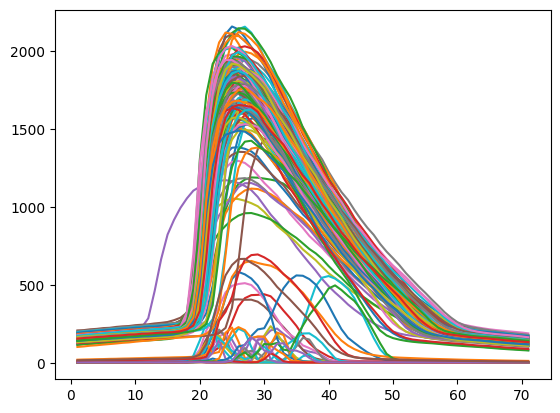

In [8]:
## For inspection only

# Group df by Metadata_Well and sort by Metadata_Z
df = df.sort_values(by='Metadata_Z')
df_grouped = df.groupby('Metadata_Well')

# Then plot the normalized variance across Z for each well
fig, ax = plt.subplots()
for name, group in df_grouped:
    ax.plot(group['Metadata_Z'], group['normalized_variance'], label=name)

In [ ]:
# Plot again but after filtering for those with a low focus

fmin = 250
#Identify the wells that meet the condition for plane 0
wells_of_interest = df.loc[
    (df['Metadata_Plane'] == 0) & (df['normalized_variance'] > fmin),
    'Metadata_Well'
].unique()

# Step 2: Filter the DataFrame to keep ALL rows that belong to those wells
filtered_df = df[df['Metadata_Well'].isin(wells_of_interest)]

# Group df by Metadata_Well and sort by Metadata_Z
filtered_df = filtered_df.sort_values(by='Metadata_Z')
df_grouped = filtered_df.groupby('Metadata_Well')

# Then plot the normalized variance across Z for each well
fig, ax = plt.subplots()
for name, group in df_grouped:
    ax.plot(group['Metadata_Z'], group['normalized_variance'], label=name)

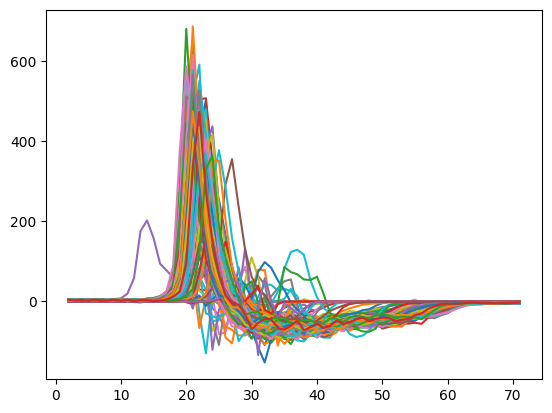

In [9]:
## For inspection only

# Group df by Metadata_Well and sort by Metadata_Z
df = df.sort_values(by='Metadata_Z')
df_grouped = df.groupby('Metadata_Well')

# Then plot the normalized variance across Z for each well
fig, ax = plt.subplots()
for name, group in df_grouped:
    ax.plot(group['Metadata_Z'], group['d_normalized_variance'], label=name)

### Inspect the first slices from our method. 

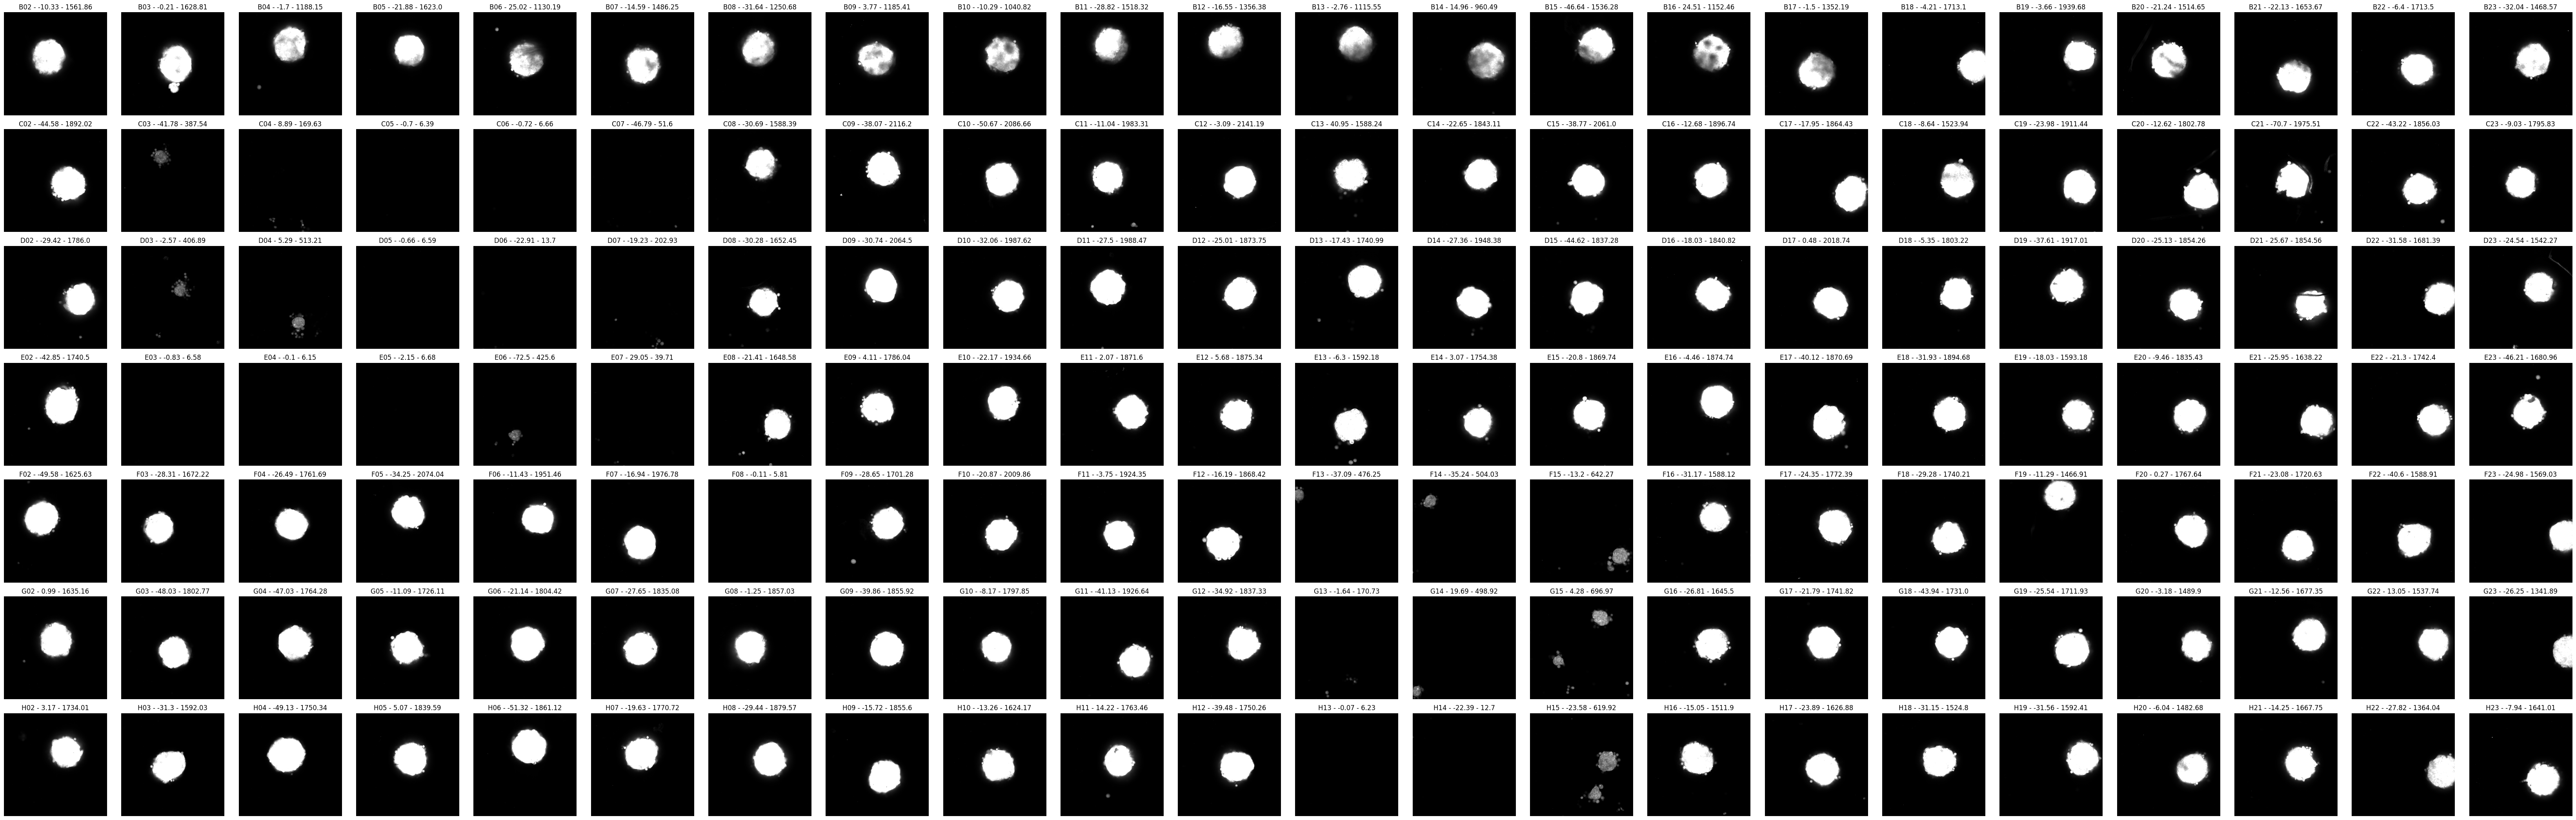

In [21]:
# 1. Filter DataFrame for your images of interest
selected = df.query('Metadata_Plane == 7').copy()

# Sort by well
selected = selected.sort_values(['Metadata_Well'])

# 2. Collect images and labels (well numbers) into lists
images = []
labels = []  # e.g. Well numbers
img_data = None
for i, row in selected.iterrows():
    image_path = row['URL_SphereDetect']
    img_data = tiff.TiffFile(image_path).asarray()
    images.append(img_data)
    
    # If your well information is in 'Metadata_Well', store it
    labels.append(str(row['Metadata_Well']) + ' - ' + str(round(row['d_normalized_variance'],2)) + ' - ' + str(round(row['normalized_variance'],2)))
    

# 3. Determine grid layout
n_images = len(images)
n_cols = 22  # Adjust as needed
n_rows = 7  # Adjust as needed

# 4. Create figure and subplots
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3 * n_cols, 3 * n_rows),  # Adjust as needed
    squeeze=False
)

# 5. Display each image, add a title, and remove axes
for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1500)
    ax.set_title(label)  
    ax.axis('off')

# Hide any leftover empty subplots if n_rows*n_cols > n_images
for ax in axes.flat[n_images:]:
    ax.axis('off')

plt.tight_layout()
plt.show()



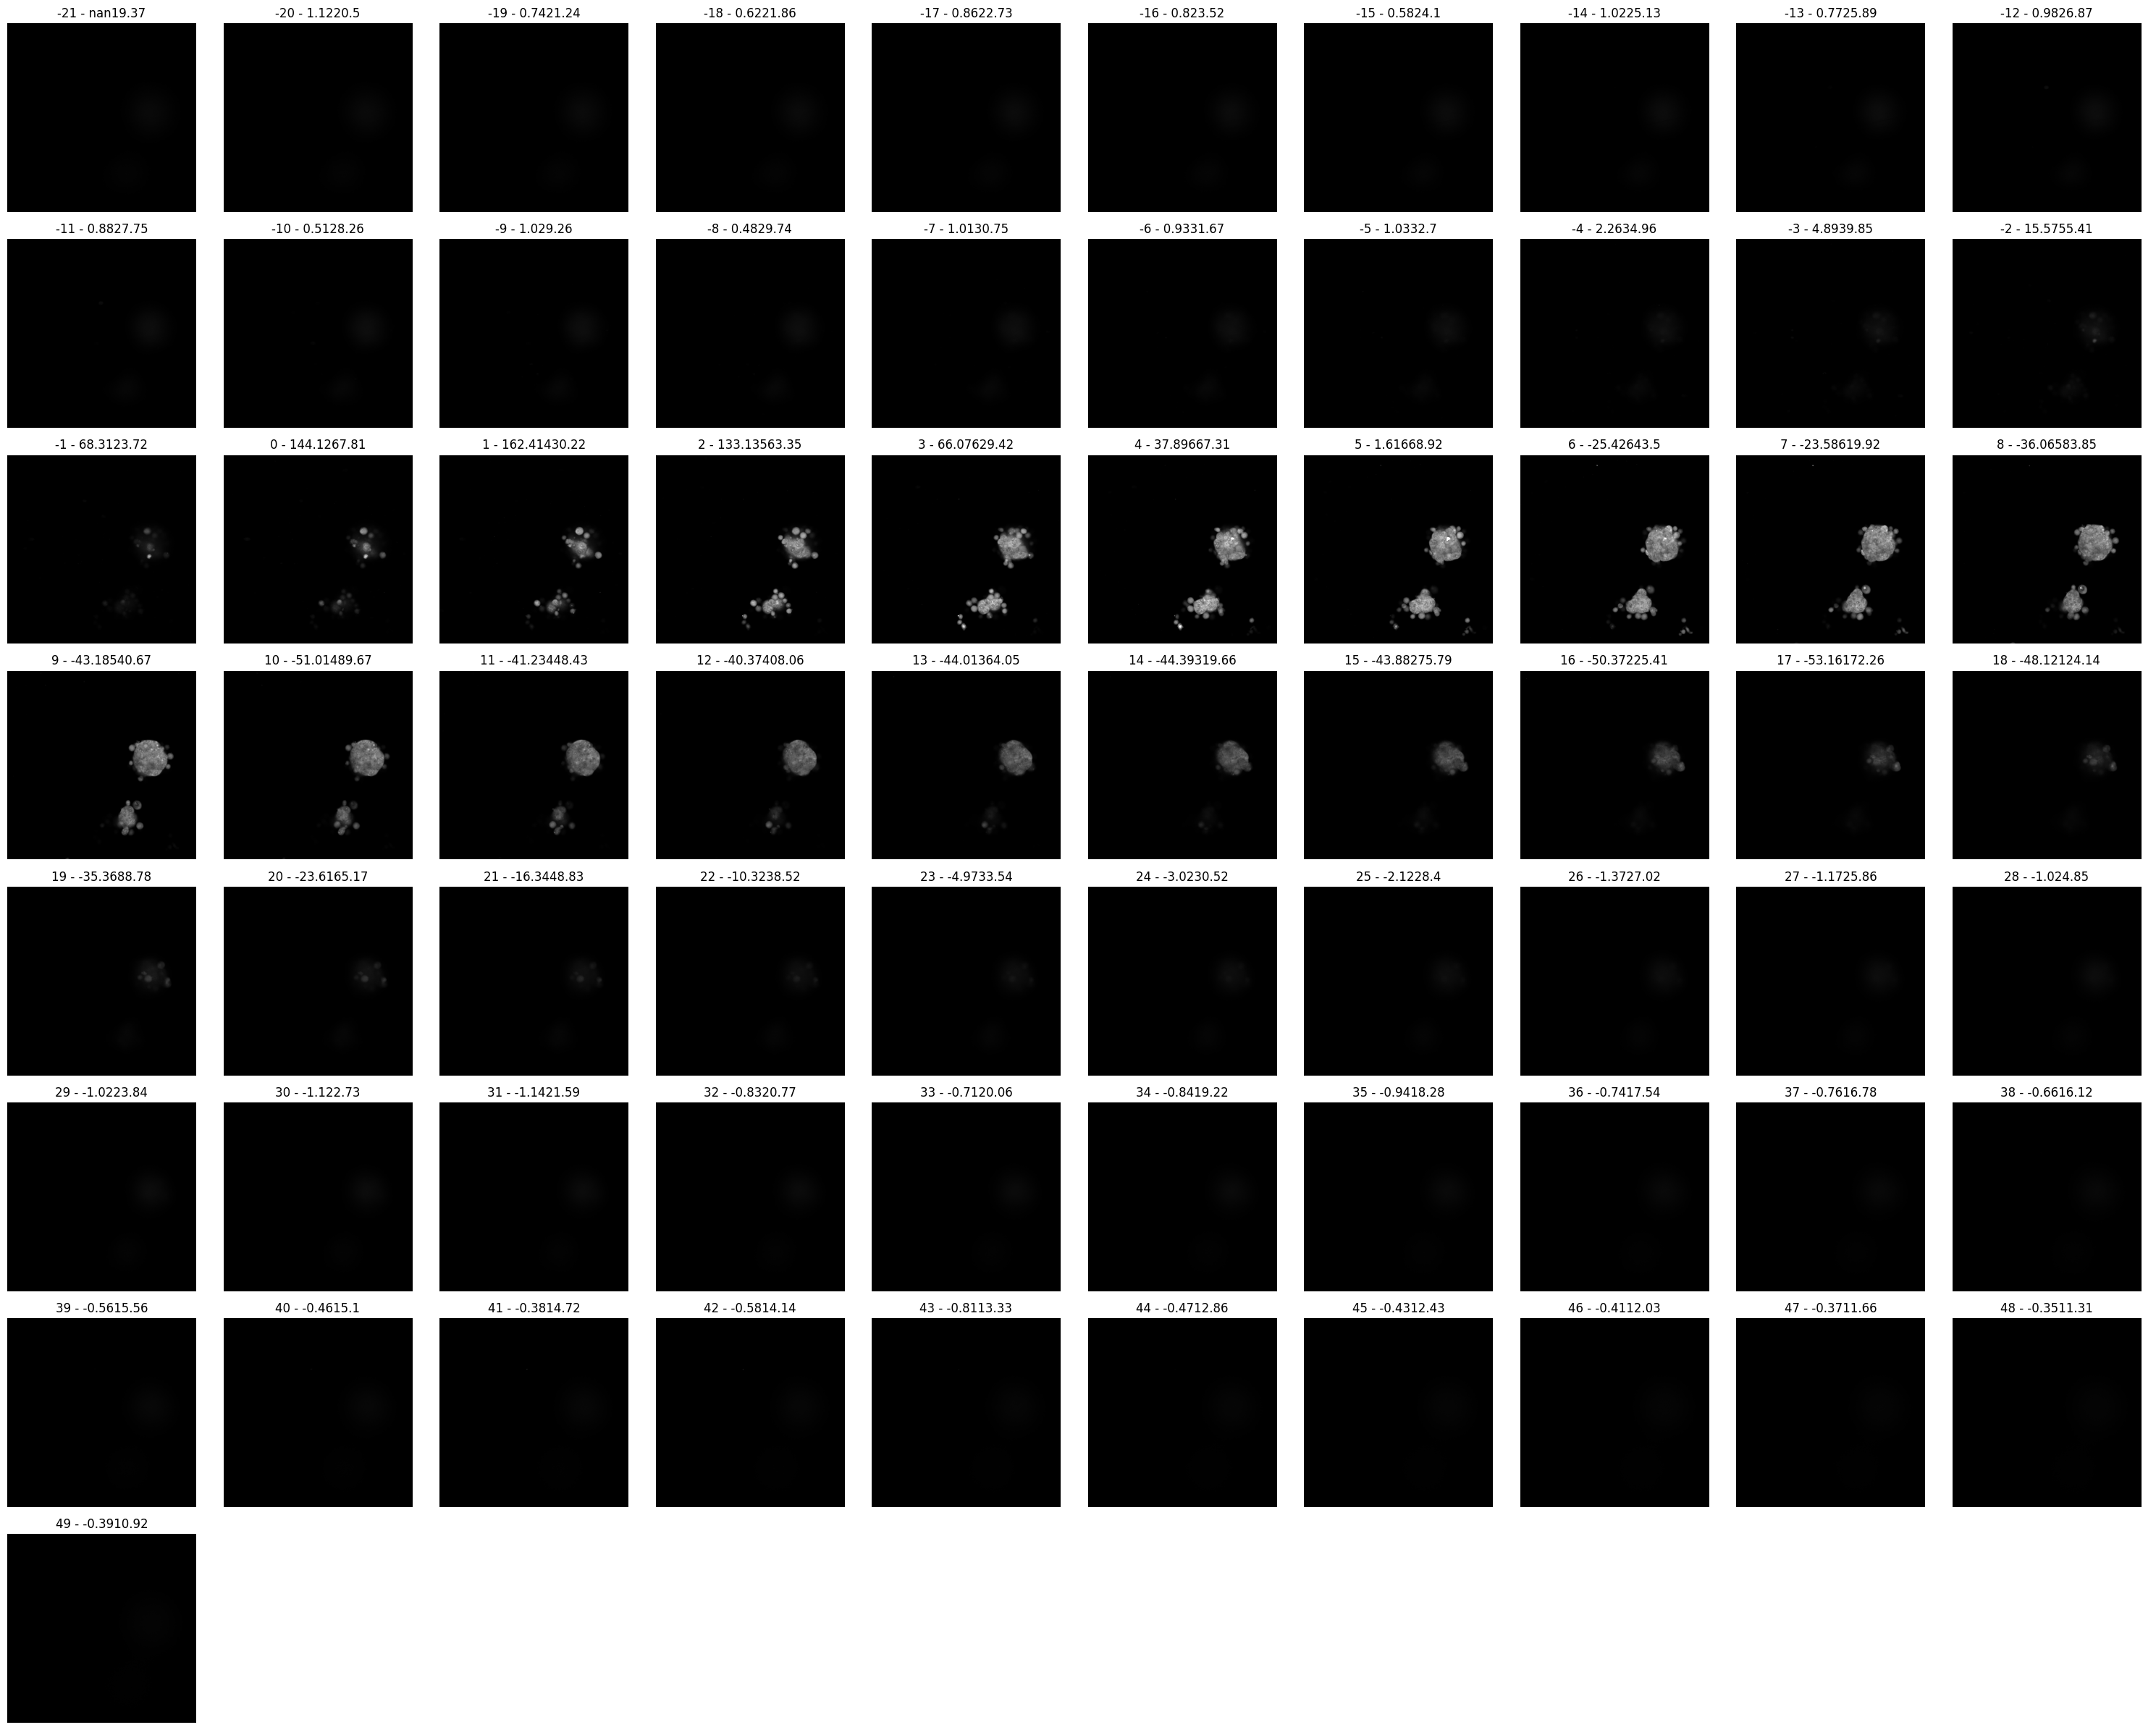

In [20]:
# Inspect a single well 

well = 'H15'

# 1. Filter DataFrame for your images of interest
selected = df.query('Metadata_Well == @well').copy()

# Sort by well
selected = selected.sort_values(['Metadata_Plane'])

# 2. Collect images and labels (well numbers) into lists
images = []
labels = []  # e.g. Well numbers
img_data = None
for i, row in selected.iterrows():
    image_path = row['URL_SphereDetect']
    img_data = tiff.TiffFile(image_path).asarray()
    images.append(img_data)
    
    # If your well information is in 'Metadata_Well', store it
    labels.append(str(row['Metadata_Plane']) + ' - ' + str(round(row['d_normalized_variance'],2)) + str(round(row['normalized_variance'],2)))

# 3. Determine grid layout
n_images = len(images)
n_cols = 10  # Adjust as needed
n_rows = 8  # Adjust as needed

# 4. Create figure and subplots
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3 * n_cols, 3 * n_rows),  # Adjust as needed
    squeeze=False
)

# 5. Display each image, add a title, and remove axes
for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1500)
    ax.set_title(label)  
    ax.axis('off')

# Hide any leftover empty subplots if n_rows*n_cols > n_images
for ax in axes.flat[n_images:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

